In [8]:
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [11]:
memory_type = torch.device('cuda')
dtype = torch.float32
num_modes = 1
study = 'TM'

# device 1

In [12]:
# parameters
lambd = 1.55

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 1

# spacing
dx = 0.05 * k_0
dy = 0.05 * k_0

# simulation lengths
core_length_x = 2 * k_0 # W
core_length_y = 1 * k_0 # H

substrate_length_x = 3.0 * k_0 # Xs
substrate_length_y = 3.0 * k_0 # Ys

# refractive indices
n_core = 1.55
n_substrate = 1.44

In [13]:
weights = [1/2, 1/2, 4, 1/4, 1, 1]
m = 2

In [14]:
lengths_x = [substrate_length_x, core_length_x, substrate_length_x]
lengths_y = [substrate_length_y, core_length_y, substrate_length_y]
RIs = [n_substrate, n_core]

In [15]:
reference_device = devices.BuriedChannelWaveguide(RIs, lambd, lengths_x, lengths_y, study, 'E')

C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


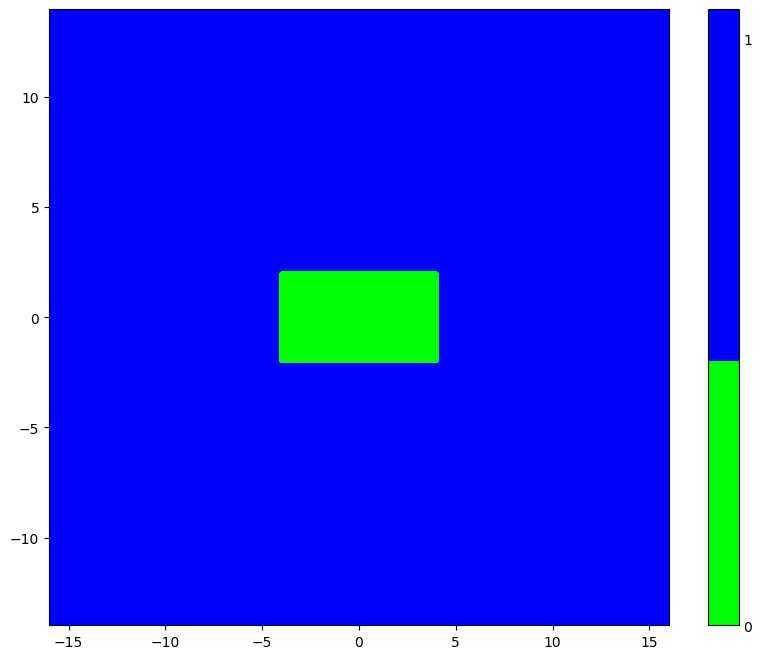

In [16]:
reference_device.plot(dx, dy)

In [17]:
torch.manual_seed(42)
base_model = models.discontinuity_capturing_network(2, 128, num_modes, 2, 'Siren')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20000], gamma=1e0)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 17153


In [18]:
# mesh = samplers.uniform_grid_2d(reference_device, dx/2, dy/2, dtype, 'cpu')
# features = reference_device.make_features(mesh)
# 
# plt.scatter(mesh[:, 0].cpu().detach(), mesh[:, 1].cpu().detach(), s=1, c=features, cmap='jet');

In [19]:
device = devices.BuriedChannelWaveguideWithPINNs(RIs, lambd, lengths_x, lengths_y, study, 'E', base_model, 1, True)

In [20]:
reference_device_fd = devices.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy)

In [21]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

  0%|          | 0/20001 [00:00<?, ?it/s]

num samples 22101


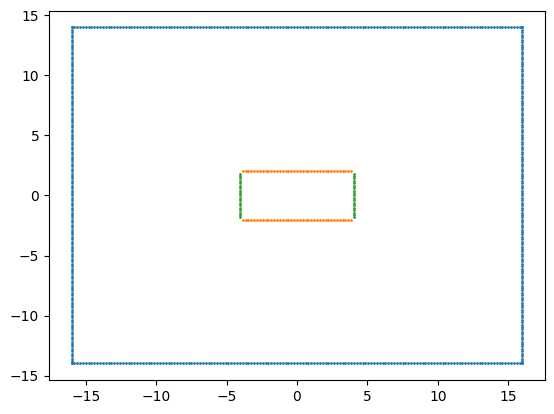

loss1 is 0.00711, loss2 is 0.0, loss3 is 0.00687, loss4 is 0.0, loss5 is 1.29409, loss6 is 0.0005, total loss 1.30856, RI value 1.44393:   0%|          | 0/20001 [00:00<?, ?it/s]

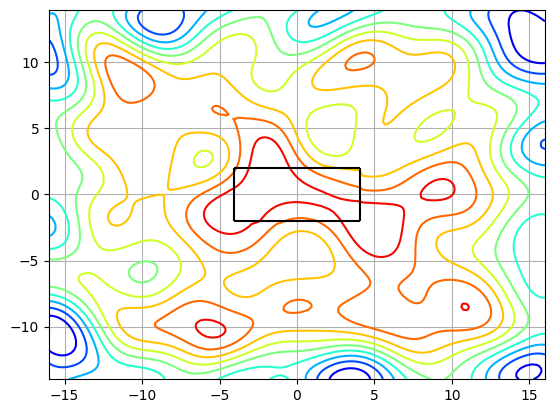

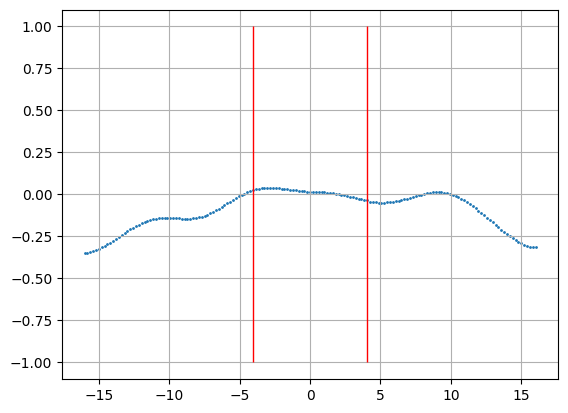

loss1 is 0.00026, loss2 is 0.00012, loss3 is 0.0002, loss4 is 0.0, loss5 is 0.00049, loss6 is 0.0001, total loss 0.00117, RI value 1.47599:   2%|▏         | 500/20001 [00:14<08:45, 37.09it/s] 

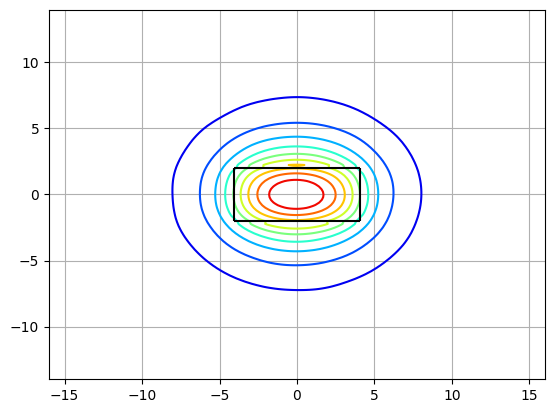

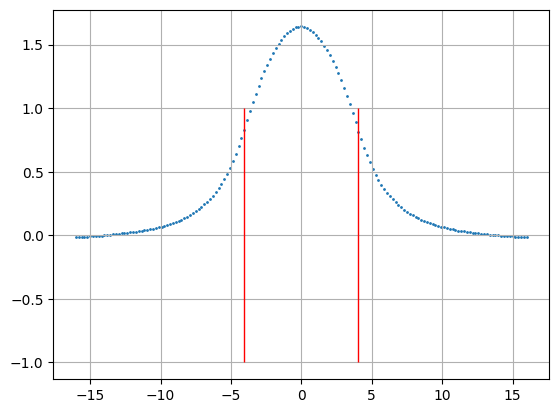

loss1 is 0.00013, loss2 is 9e-05, loss3 is 0.0001, loss4 is 0.0, loss5 is 0.0, loss6 is 9e-05, total loss 0.00041, RI value 1.47555:   5%|▍         | 1000/20001 [00:29<09:07, 34.70it/s]       

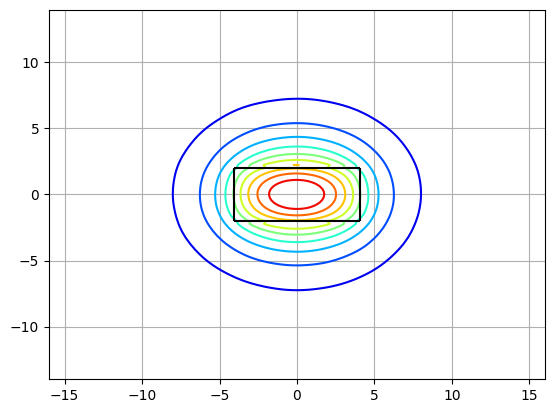

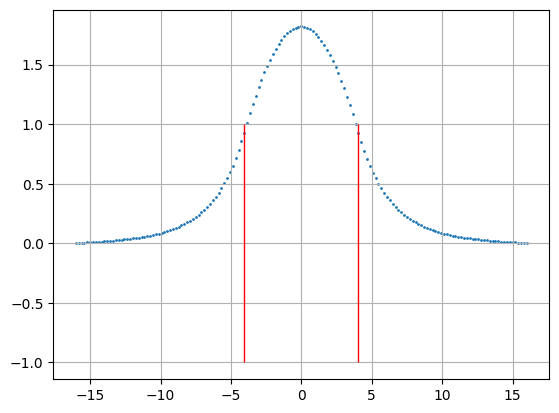

loss1 is 8e-05, loss2 is 6e-05, loss3 is 6e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 9e-05, total loss 0.0003, RI value 1.47513:   7%|▋         | 1497/20001 [00:43<08:25, 36.59it/s]          

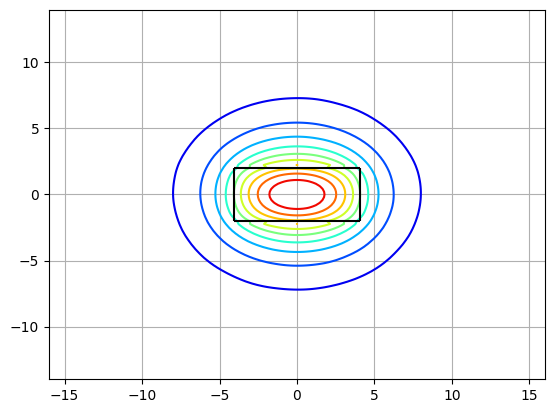

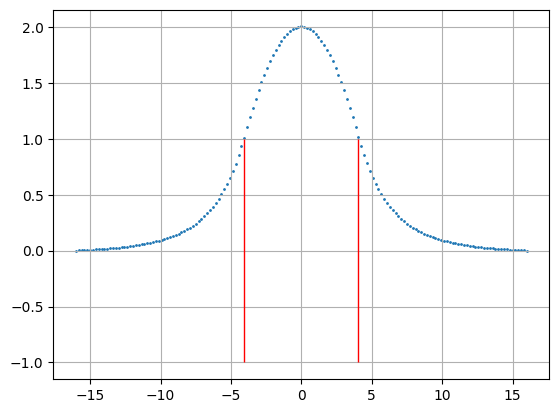

loss1 is 7e-05, loss2 is 4e-05, loss3 is 5e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 9e-05, total loss 0.00025, RI value 1.47431:  10%|▉         | 1997/20001 [00:57<08:26, 35.58it/s]      

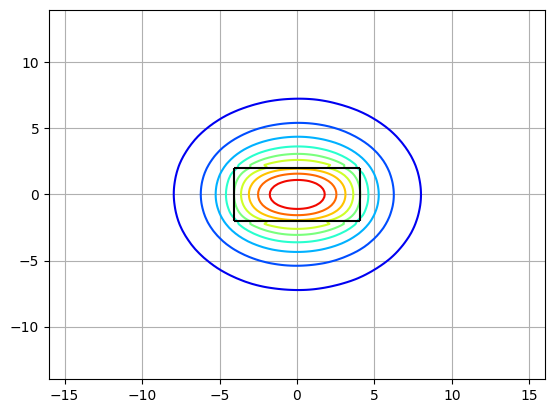

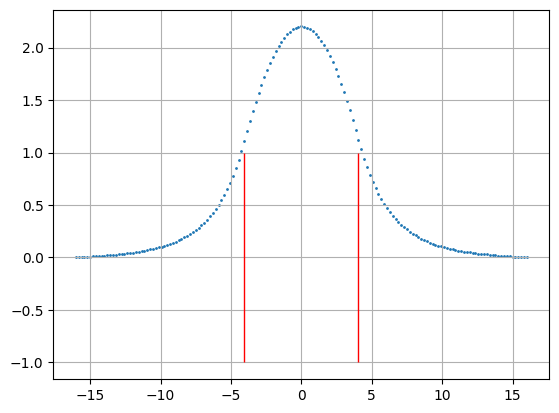

loss1 is 4e-05, loss2 is 3e-05, loss3 is 3e-05, loss4 is 0.0, loss5 is 0.00034, loss6 is 9e-05, total loss 0.00053, RI value 1.47439:  12%|█▏        | 2500/20001 [01:11<08:10, 35.66it/s]

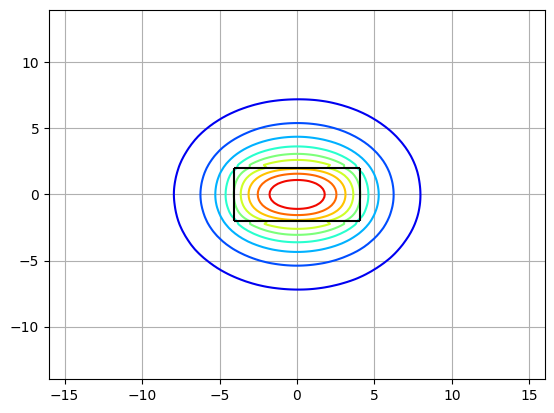

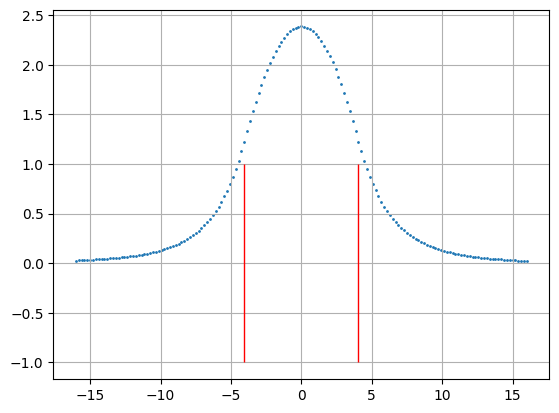

loss1 is 3e-05, loss2 is 3e-05, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 9e-05, total loss 0.00017, RI value 1.47439:  15%|█▍        | 2997/20001 [01:25<08:03, 35.18it/s]    

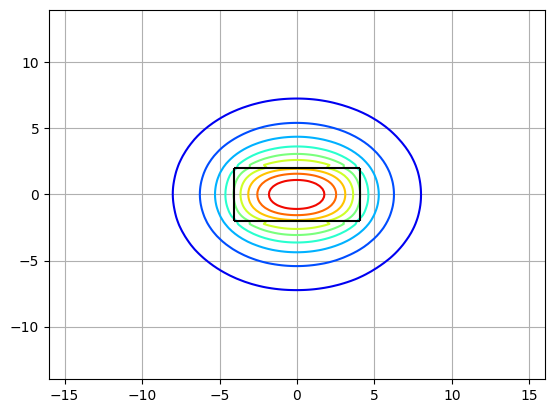

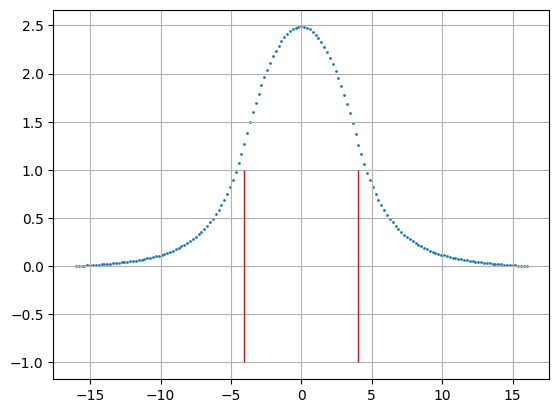

loss1 is 3e-05, loss2 is 2e-05, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 9e-05, total loss 0.00016, RI value 1.47425:  17%|█▋        | 3499/20001 [01:40<07:32, 36.44it/s]    

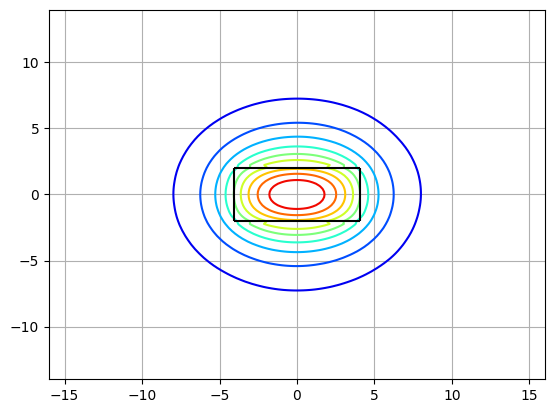

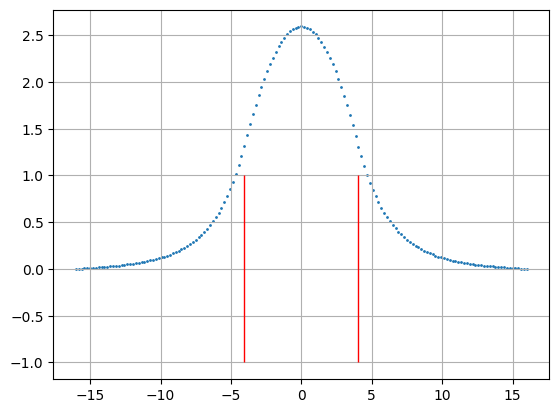

loss1 is 4e-05, loss2 is 2e-05, loss3 is 3e-05, loss4 is 0.0, loss5 is 0.00167, loss6 is 9e-05, total loss 0.00184, RI value 1.47433:  20%|█▉        | 3999/20001 [01:54<07:41, 34.68it/s]

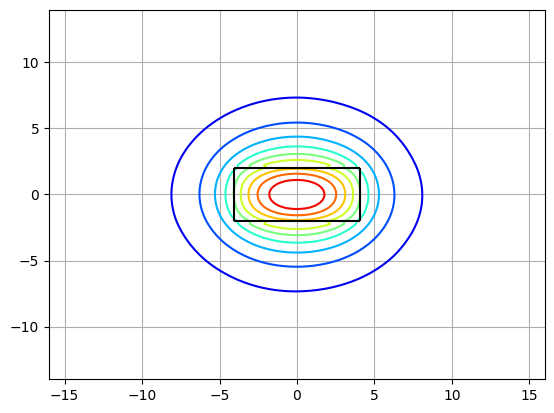

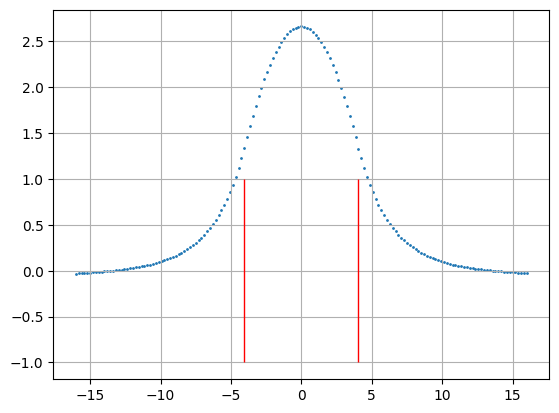

loss1 is 2e-05, loss2 is 2e-05, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00014, RI value 1.4744:  22%|██▏       | 4500/20001 [02:08<07:25, 34.78it/s]     

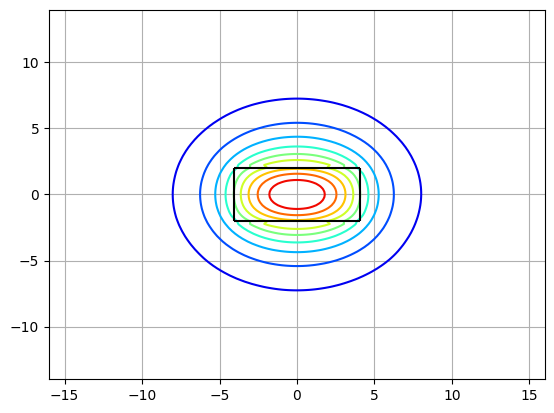

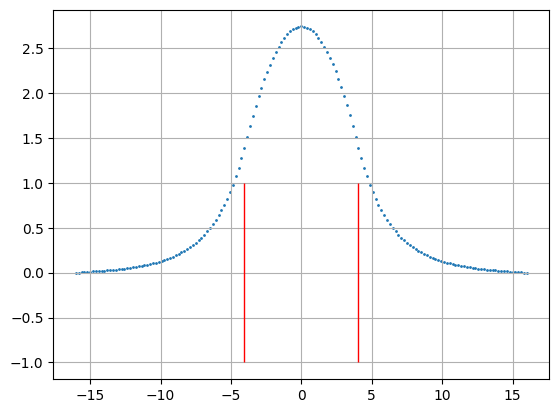

loss1 is 3e-05, loss2 is 2e-05, loss3 is 3e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 9e-05, total loss 0.00016, RI value 1.4742:  25%|██▍       | 5000/20001 [02:23<07:17, 34.30it/s]     

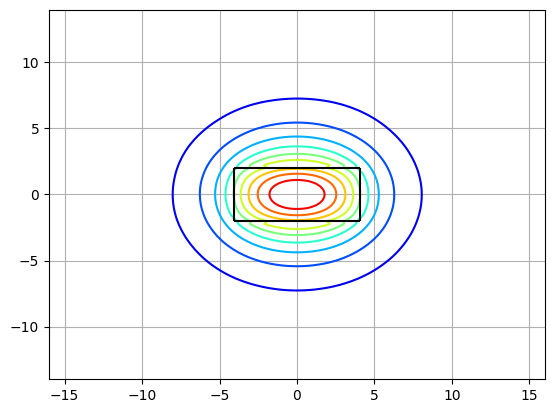

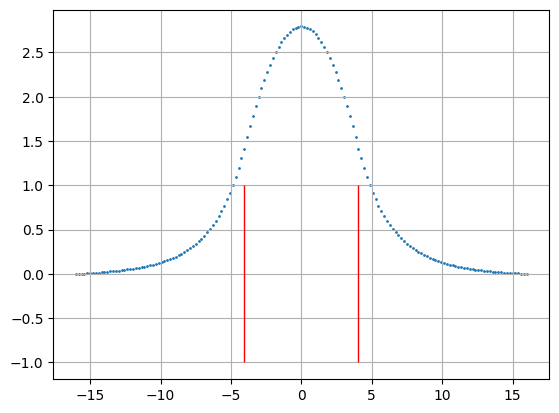

loss1 is 2e-05, loss2 is 2e-05, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00014, RI value 1.47425:  27%|██▋       | 5500/20001 [02:37<06:53, 35.11it/s]    

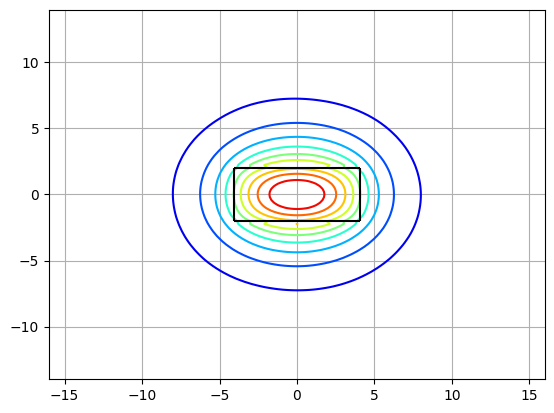

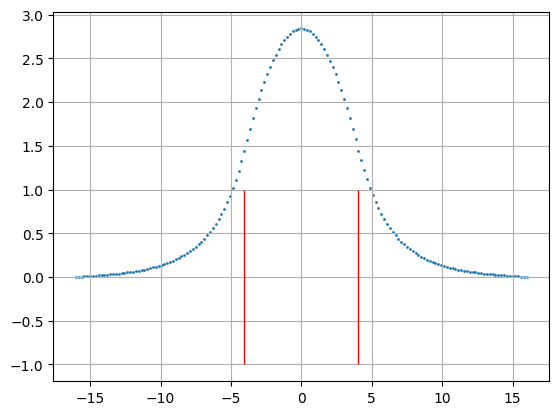

loss1 is 2e-05, loss2 is 1e-05, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00014, RI value 1.47432:  30%|██▉       | 6000/20001 [02:52<06:40, 34.99it/s]    

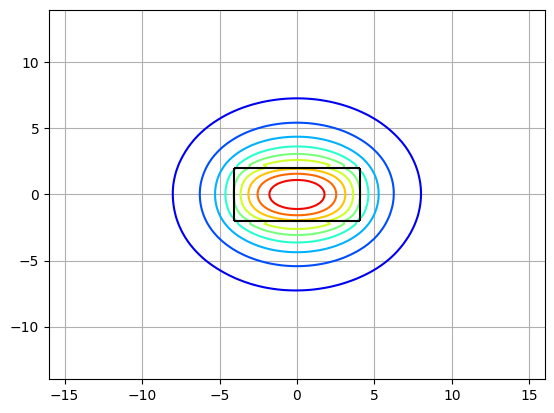

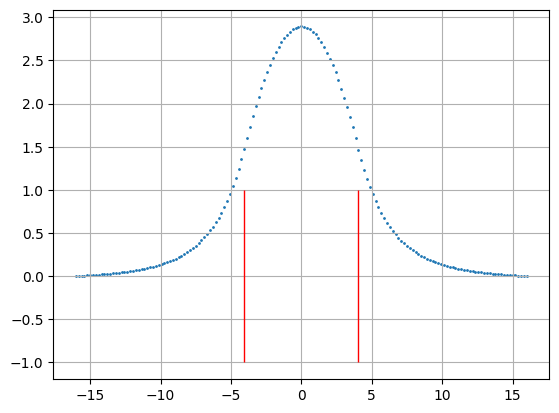

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00013, RI value 1.47428:  32%|███▏      | 6499/20001 [03:07<06:20, 35.48it/s]    

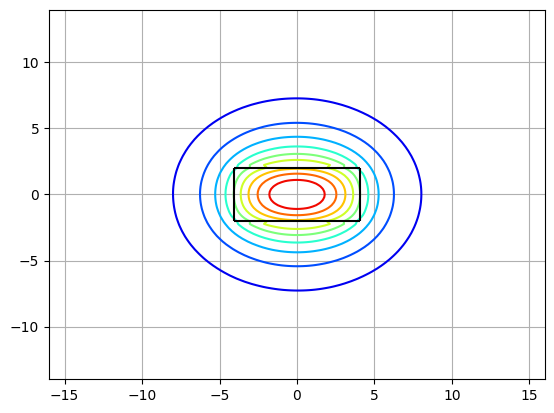

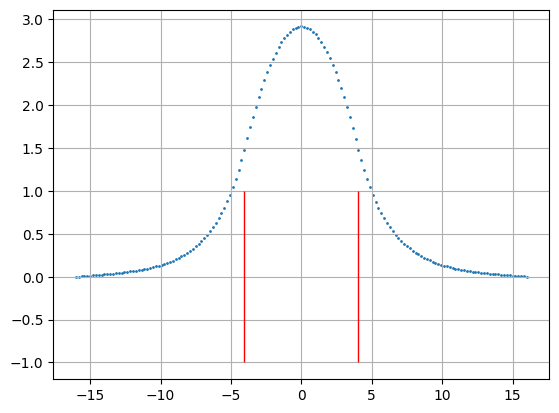

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.47435:  35%|███▍      | 6999/20001 [03:21<06:08, 35.26it/s]    

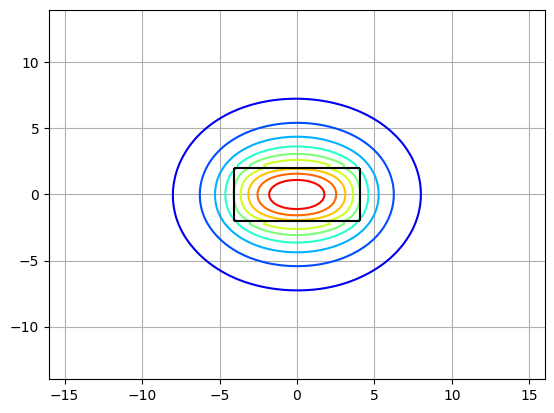

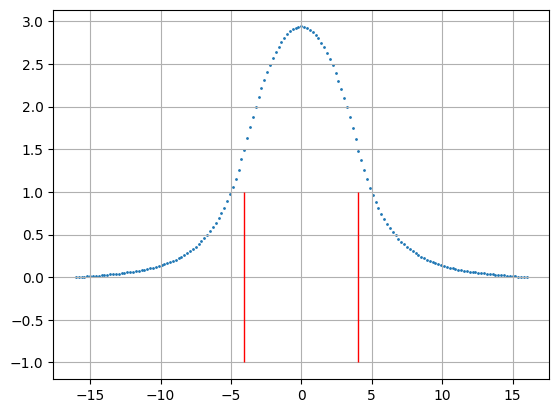

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00013, RI value 1.47426:  37%|███▋      | 7499/20001 [03:35<06:07, 34.05it/s]    

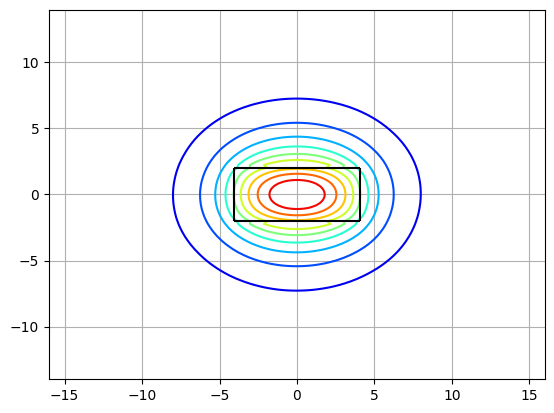

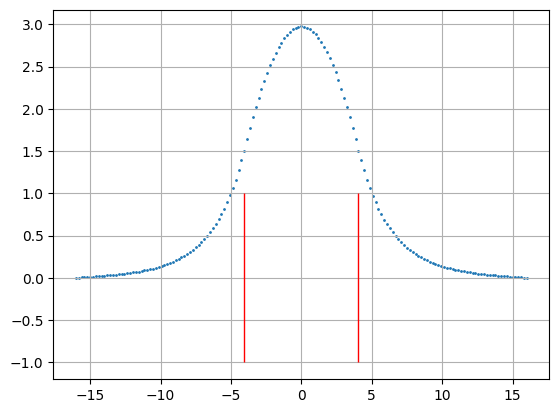

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.47429:  40%|███▉      | 7999/20001 [03:50<05:36, 35.70it/s]    

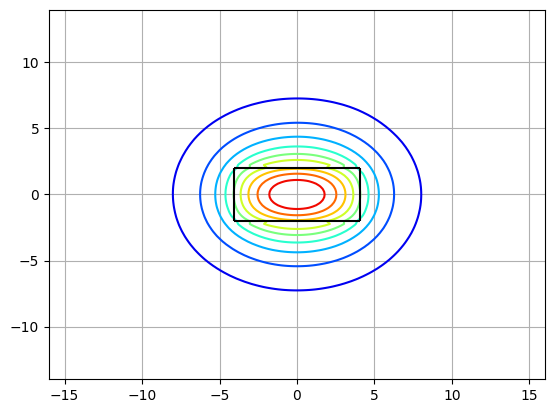

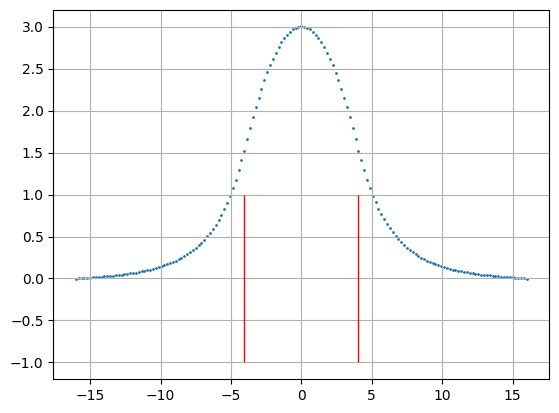

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.47432:  42%|████▏     | 8499/20001 [04:05<05:24, 35.46it/s]    

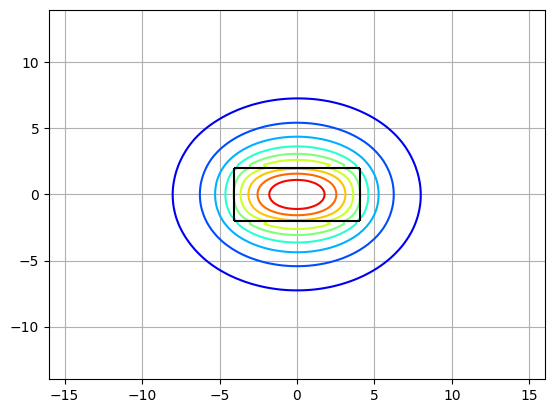

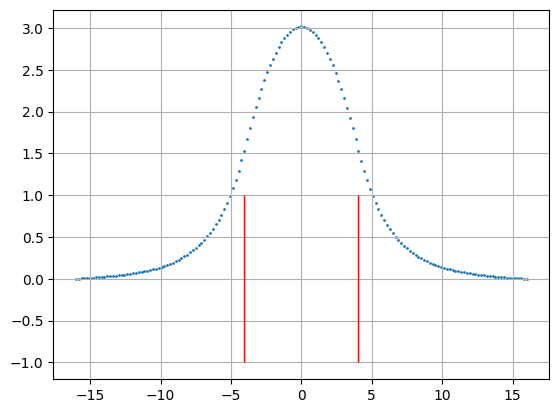

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.4743:  45%|████▍     | 8999/20001 [04:19<05:12, 35.18it/s]     

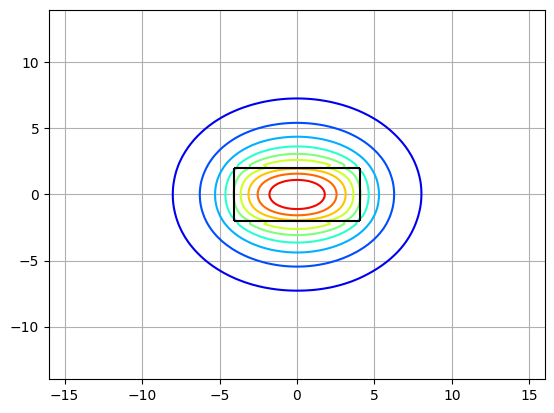

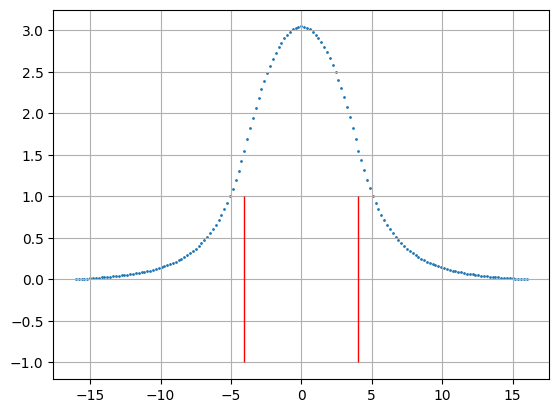

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.47426:  47%|████▋     | 9499/20001 [04:34<04:59, 35.01it/s]    

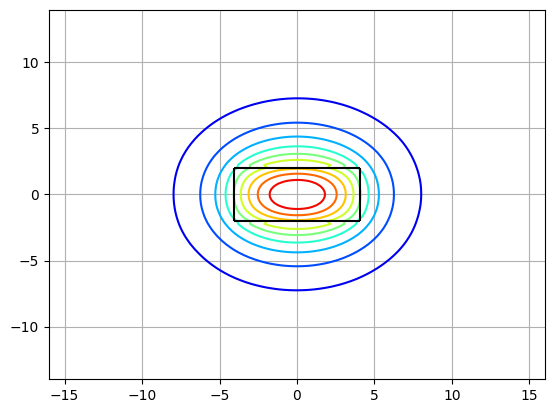

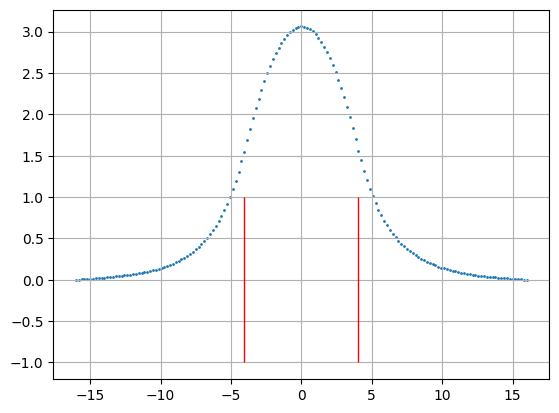

loss1 is 3e-05, loss2 is 1e-05, loss3 is 2e-05, loss4 is 0.0, loss5 is 5e-05, loss6 is 8e-05, total loss 0.00019, RI value 1.47428:  50%|████▉     | 9999/20001 [04:49<04:46, 34.97it/s]  

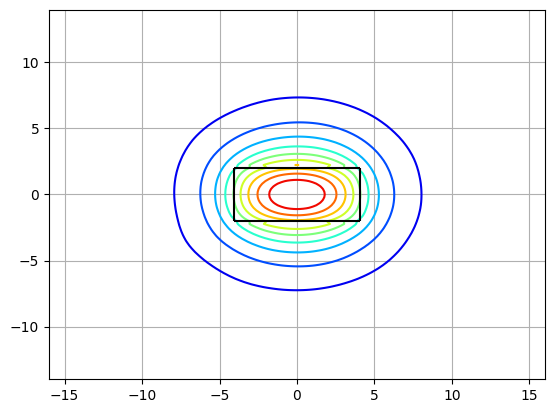

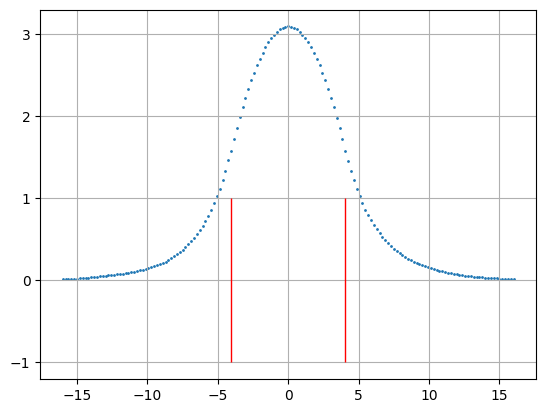

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00011, RI value 1.47435:  52%|█████▏    | 10500/20001 [05:03<04:34, 34.66it/s]    

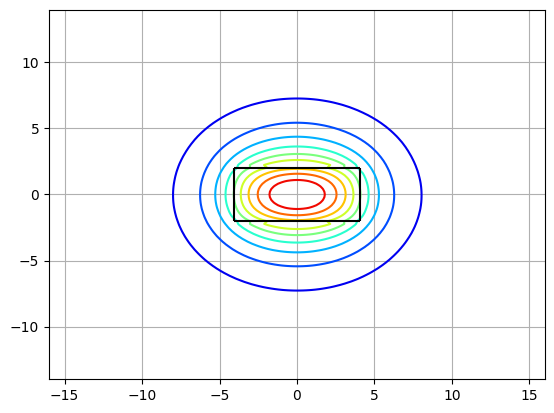

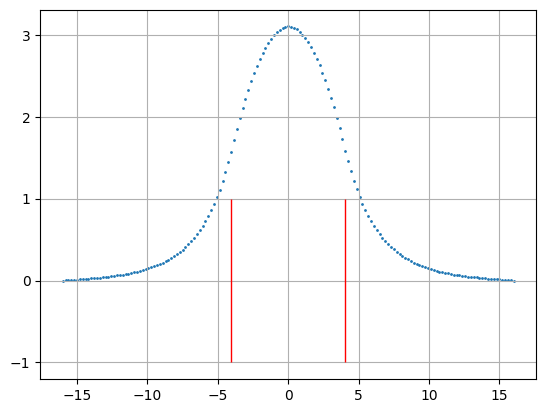

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.47433:  55%|█████▍    | 11000/20001 [05:18<04:18, 34.82it/s]    

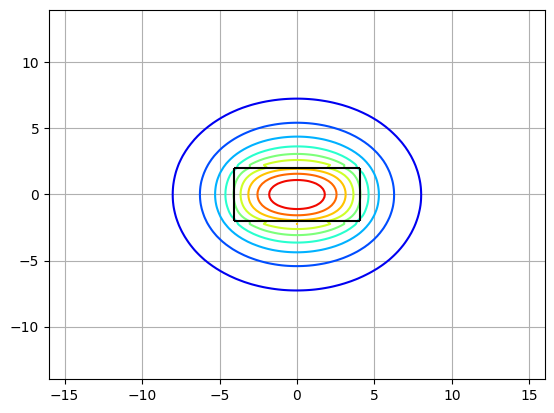

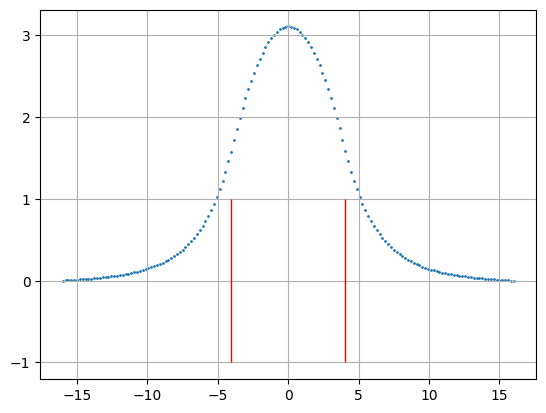

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00013, RI value 1.47424:  57%|█████▋    | 11500/20001 [05:33<04:11, 33.81it/s]    

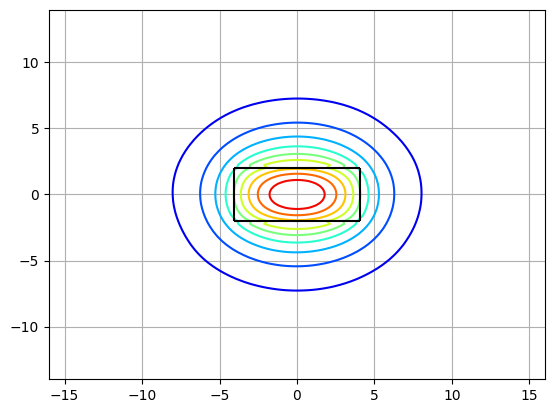

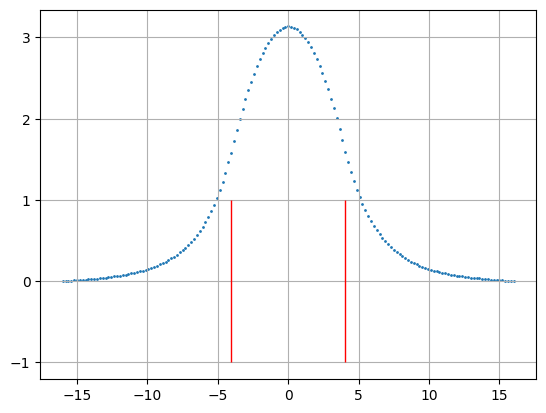

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 1e-05, loss6 is 8e-05, total loss 0.00012, RI value 1.47435:  60%|█████▉    | 11997/20001 [05:47<03:49, 34.91it/s]  

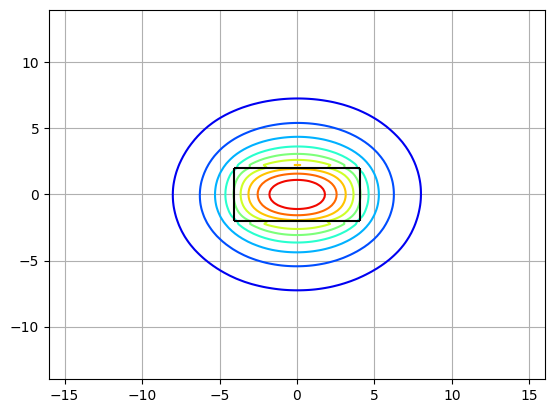

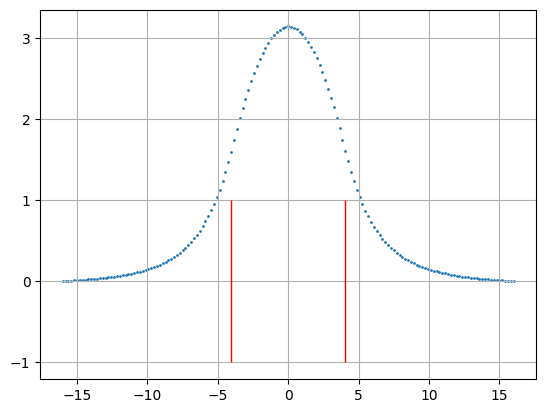

loss1 is 2e-05, loss2 is 1e-05, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00013, RI value 1.47439:  62%|██████▏   | 12498/20001 [06:02<03:26, 36.33it/s]    

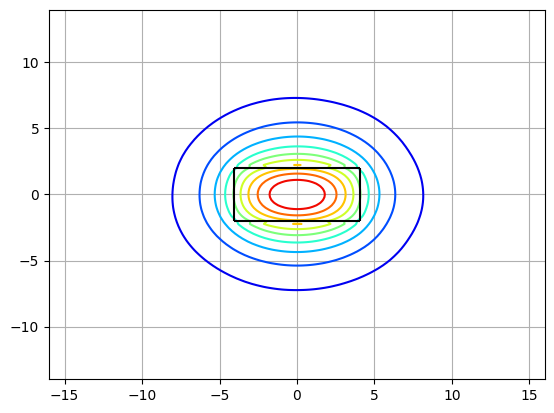

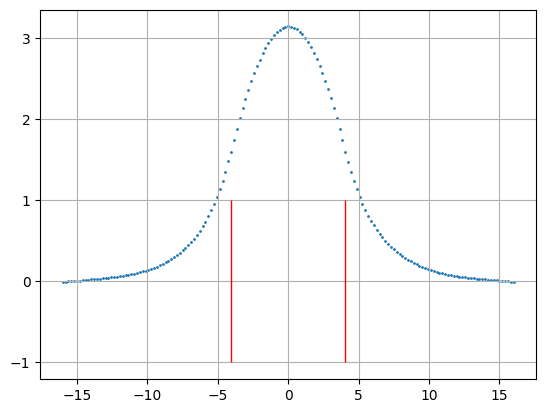

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00011, RI value 1.47434:  65%|██████▍   | 12998/20001 [06:17<03:19, 35.07it/s]    

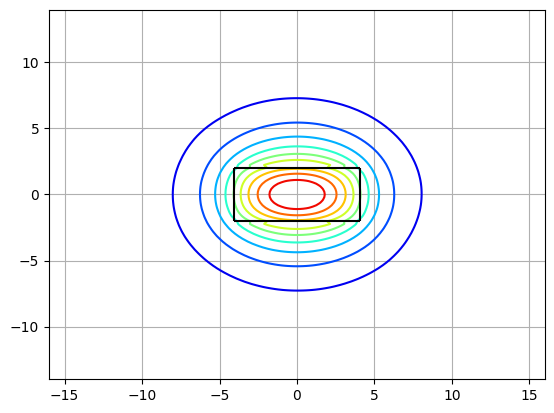

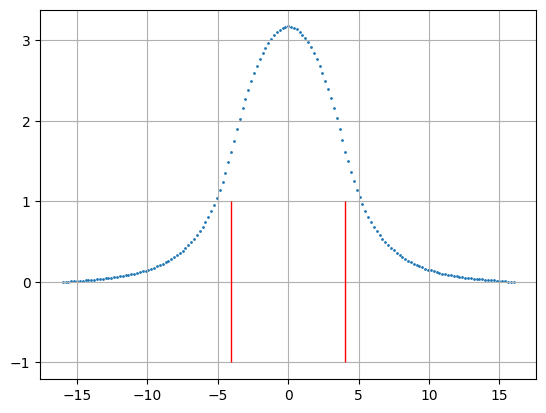

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00011, RI value 1.47427:  67%|██████▋   | 13500/20001 [06:31<03:04, 35.33it/s]    

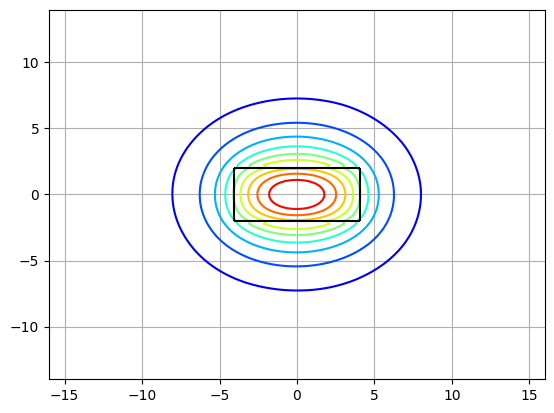

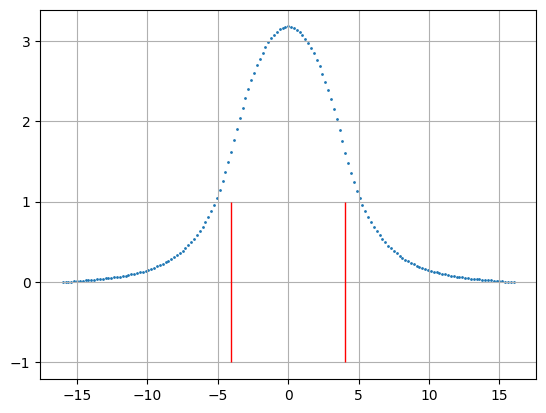

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.47433:  70%|██████▉   | 13998/20001 [06:46<02:48, 35.64it/s]    

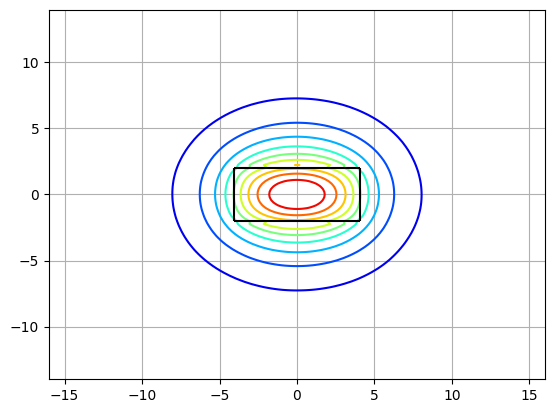

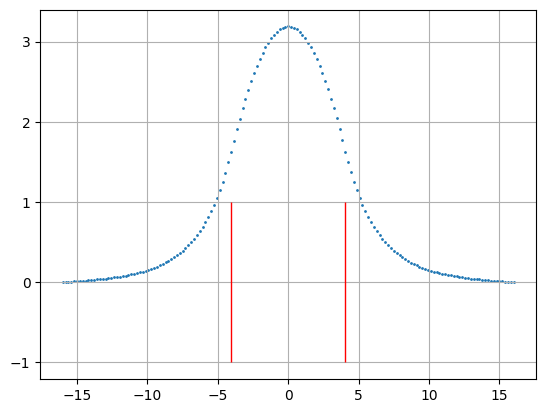

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.4743:  72%|███████▏  | 14499/20001 [07:00<02:33, 35.82it/s]     

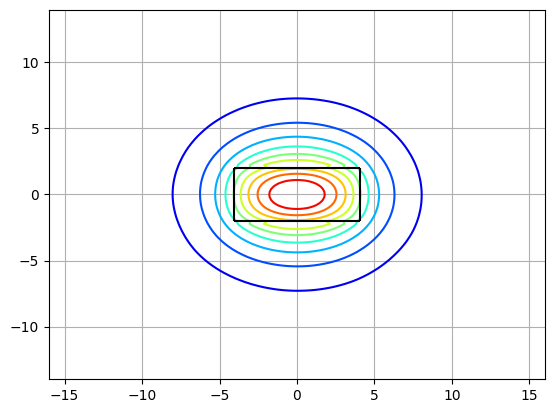

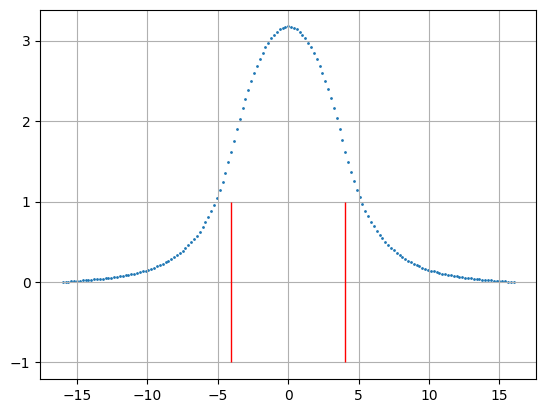

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00011, RI value 1.47434:  75%|███████▍  | 14999/20001 [07:15<02:22, 35.09it/s]    

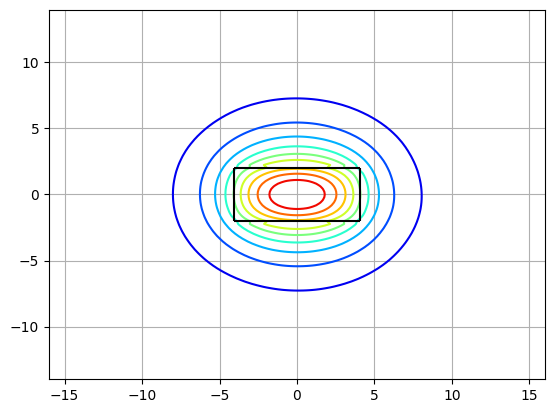

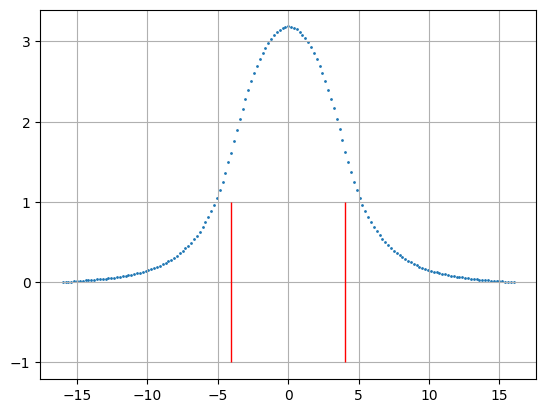

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00011, RI value 1.47438:  77%|███████▋  | 15499/20001 [07:29<02:09, 34.86it/s]    

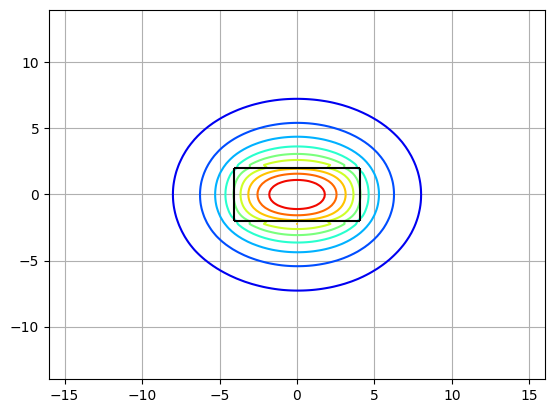

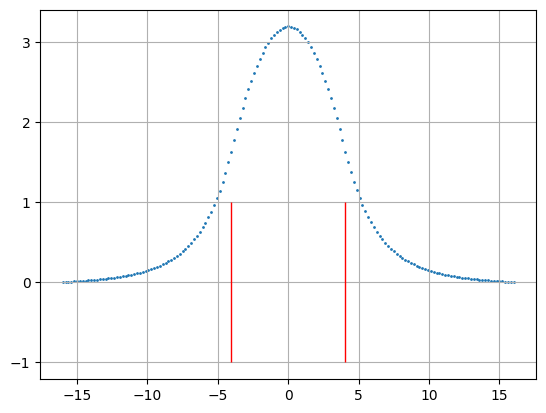

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 1e-05, loss6 is 8e-05, total loss 0.00011, RI value 1.47432:  80%|███████▉  | 16000/20001 [07:44<01:54, 35.08it/s]  

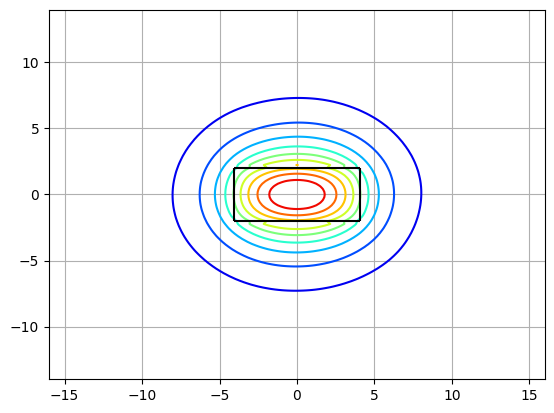

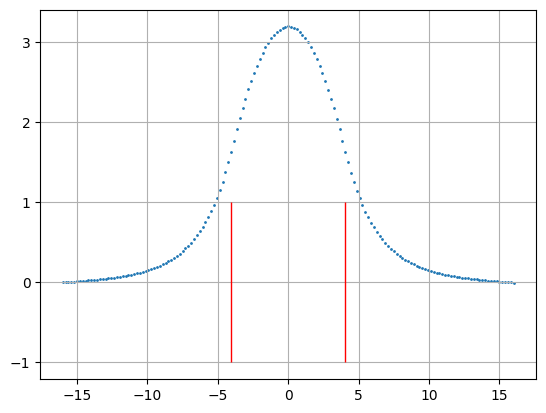

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00011, RI value 1.47429:  82%|████████▏ | 16497/20001 [07:59<01:38, 35.70it/s]    

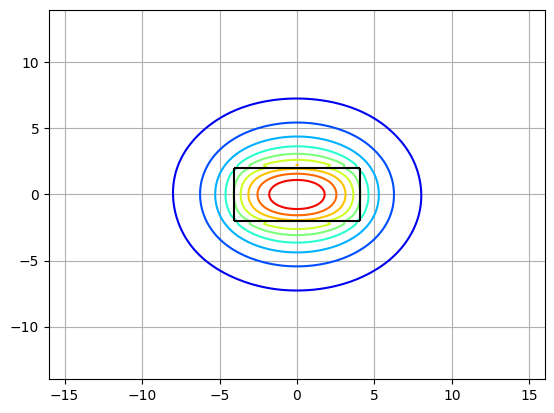

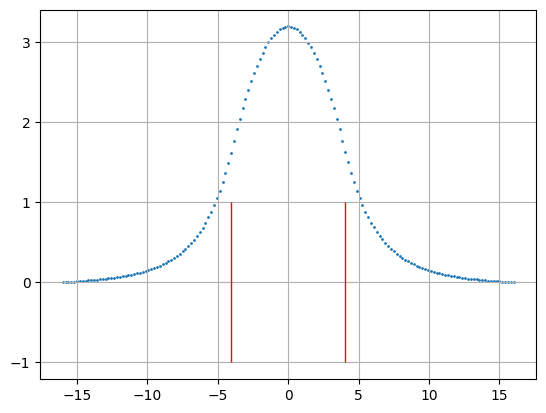

loss1 is 2e-05, loss2 is 1e-05, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00013, RI value 1.47427:  85%|████████▍ | 16997/20001 [08:13<01:27, 34.26it/s]    

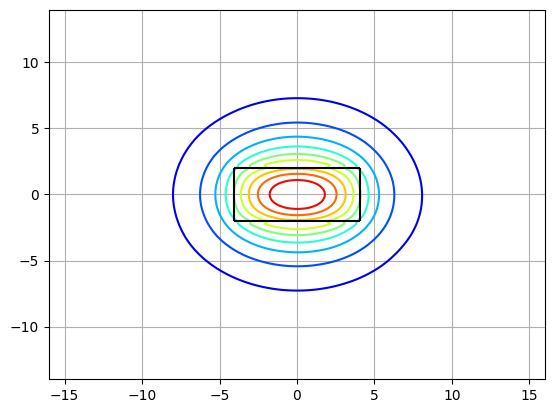

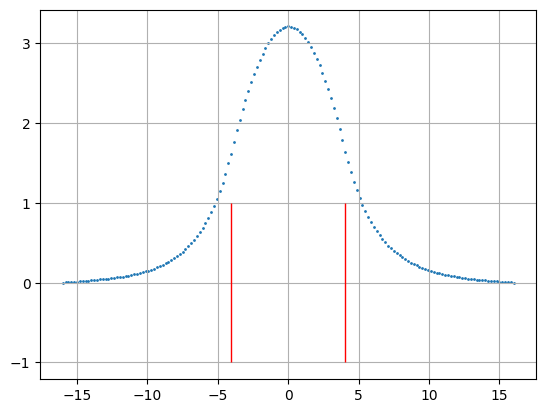

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00011, RI value 1.47439:  87%|████████▋ | 17497/20001 [08:28<01:12, 34.44it/s]    

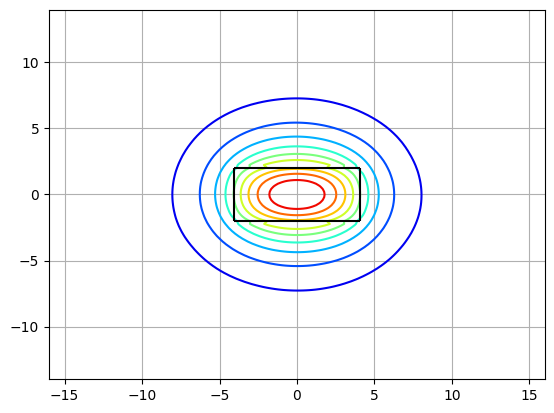

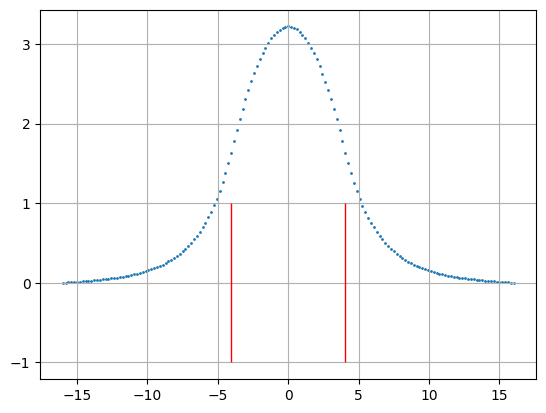

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 1e-05, loss6 is 8e-05, total loss 0.00012, RI value 1.4743:  90%|████████▉ | 17997/20001 [08:43<01:02, 32.13it/s]   

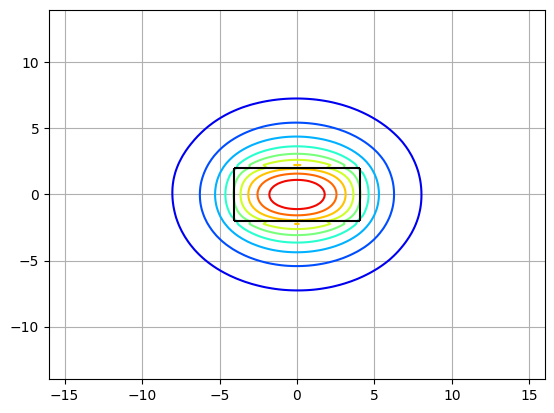

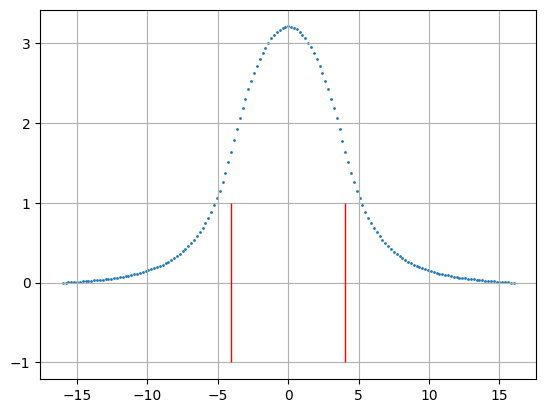

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.47425:  92%|█████████▏| 18497/20001 [08:59<00:45, 33.29it/s]    

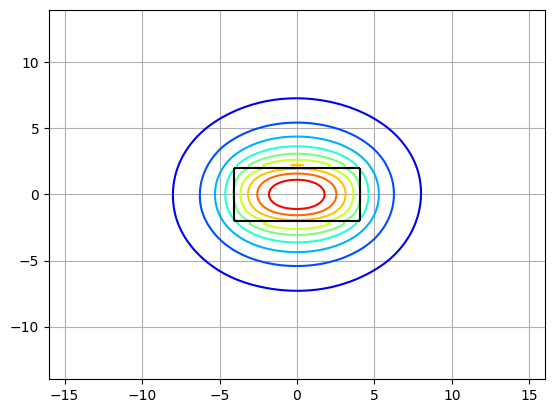

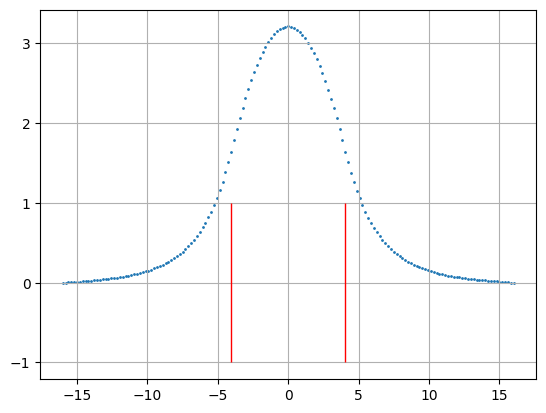

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00012, RI value 1.47429:  95%|█████████▍| 18997/20001 [09:13<00:28, 35.85it/s]    

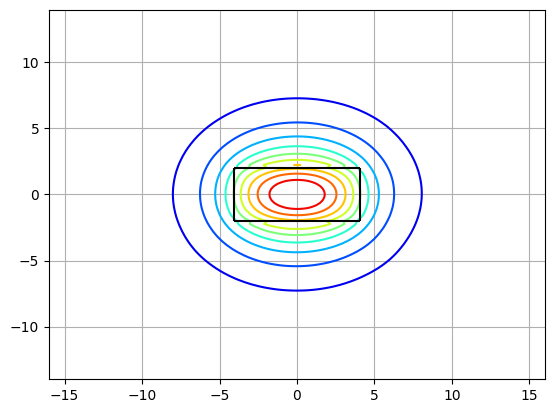

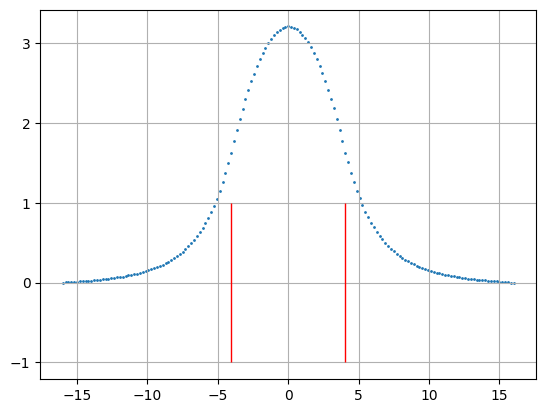

loss1 is 2e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00013, RI value 1.47428:  97%|█████████▋| 19497/20001 [09:27<00:13, 36.95it/s]    

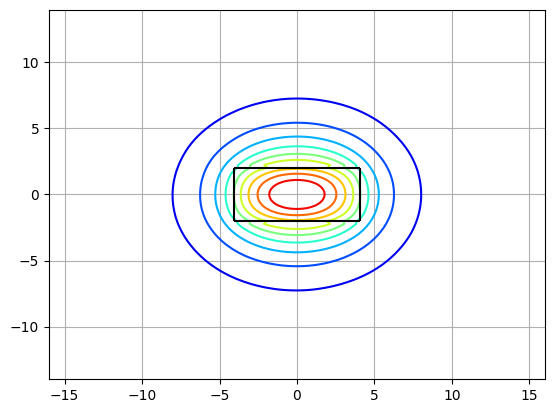

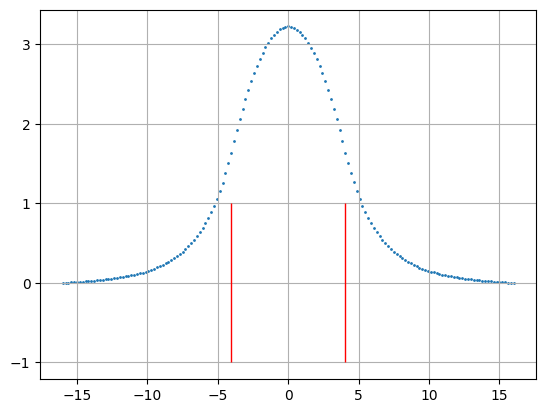

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00011, RI value 1.47439: 100%|█████████▉| 19997/20001 [09:41<00:00, 36.05it/s]    

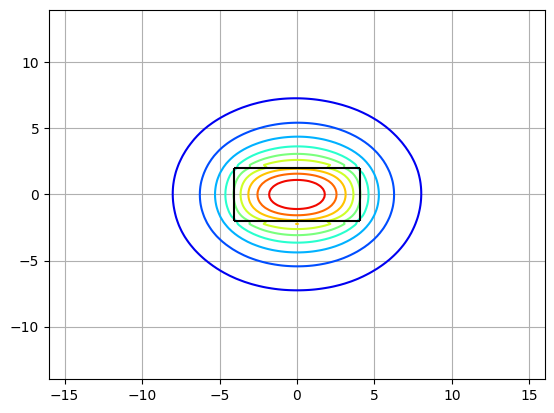

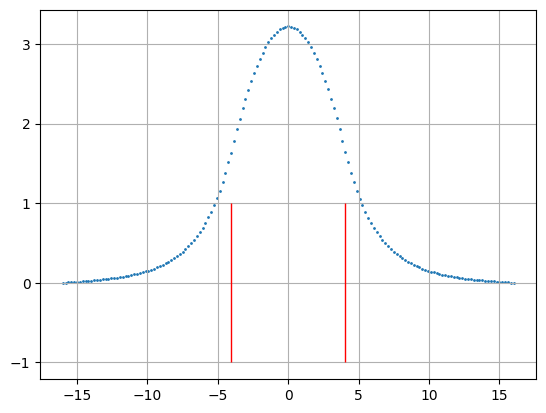

loss1 is 1e-05, loss2 is 1e-05, loss3 is 1e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 8e-05, total loss 0.00011, RI value 1.47439: 100%|██████████| 20001/20001 [09:41<00:00, 34.41it/s]


In [22]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(20001, num_modes, weights=weights, m=m, verbose=10, calc_error=False, plot_solution=True, sample_new=False)

In [23]:
base_model.to('cpu');
base_model.to(torch.float64)

Sequential(
  (0): Linear(in_features=3, out_features=128, bias=True)
  (1): Siren()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): Siren()
  (4): Linear(in_features=128, out_features=1, bias=True)
)

In [24]:
# yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
# end_val_yu = yu[-1]
# yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
# end_val_yb = yb[-1]
# xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

# xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
# # if device.augmented_input:
# #   xy = torch.cat((xy, (1/reference_device.regions(xy, format='torch').view(-1, 1))), dim=-1)
# u = base_model.forward_with_features(xy.cpu()).cpu()

In [25]:
# plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
# plt.grid()

In [26]:
xy_line = torch.arange(0, device.total_length_x/2, dx/2, dtype=torch.float64).reshape(-1, 1)
xy_line = torch.cat((-torch.flip(xy_line, dims=(0,))[:-1], xy_line))

xy_line = torch.cat((xy_line, torch.full_like(xy_line, 0*dx)), dim=-1)
if device.augmented_input:
  xy_line = torch.cat((xy_line, (reference_device.make_features(xy_line).view(-1, 1))), dim=-1)
u = base_model(xy_line.cpu()).cpu()[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()

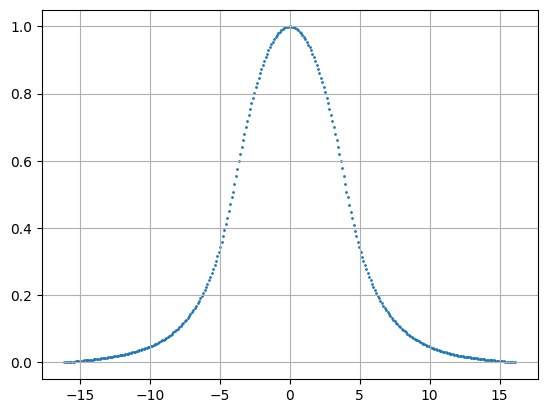

In [27]:
plt.scatter(xy_line[:, 0].cpu().detach(), u, s=1)
plt.grid()

In [28]:
len(xy_line[:])

319

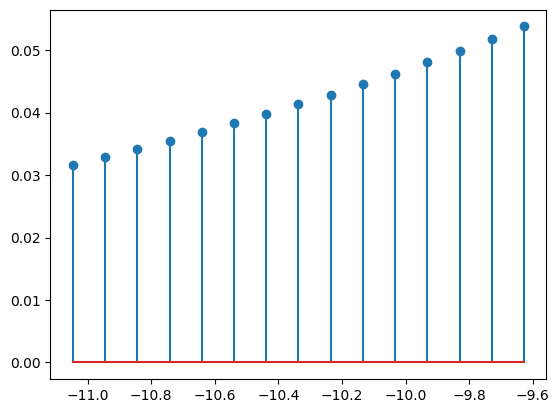

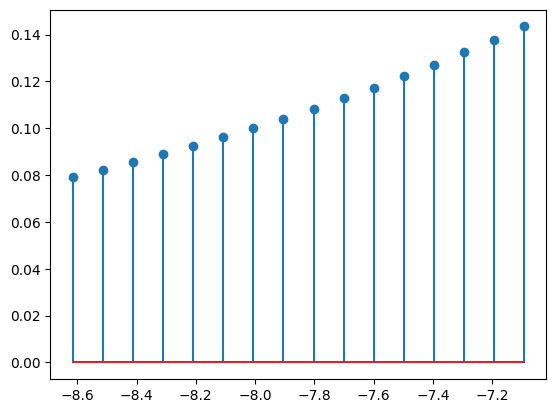

In [29]:
plt.stem(xy_line[50:65, 0].detach().numpy(), u[50:65, 0].detach().numpy())
plt.show()
plt.stem(xy_line[75-1:90, 0].detach().numpy(), u[75-1:90, 0].detach().numpy())
plt.show()

In [30]:
reference_device_fd = devices.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx/2, dy/2, num_modes=num_modes)

In [31]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float64)
xy = torch.cat((xy_fd, device.make_features(xy_fd)), dim=-1)

print(np.sqrt(RI_squared))

[1.47489339]


In [32]:
xy.requires_grad = True
NN_EI = [device.calculate_eigen_value(xy.to('cpu'), 0).item()**(1/2)]
print(NN_EI)
xy.requires_grad = False

[1.4743936265096773]


In [33]:
Nx = int(sum(lengths_x)//(dx/2))
Ny = int(sum(lengths_y)//(dy/2))

print(len(u_fd), Nx*Ny)

89001 89001


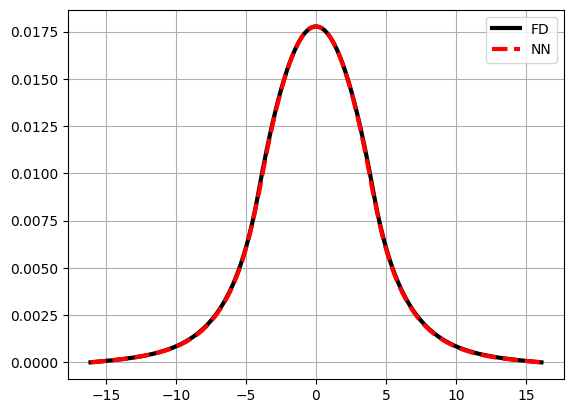

In [34]:
i = int(Ny//2)
row_length = Nx
plt.plot(xy_fd[row_length * i: row_length * (i + 1), 0], u_fd[row_length * i:row_length * (i + 1), 0], linewidth=3, label='FD', color='black')
plt.plot(xy_fd[row_length * i: row_length * (i + 1), 0], u*np.max(np.abs(u_fd[row_length * i:row_length * (i + 1), 0])), linestyle='dashed', label='NN', color='red', linewidth=3)
plt.legend()
plt.grid()

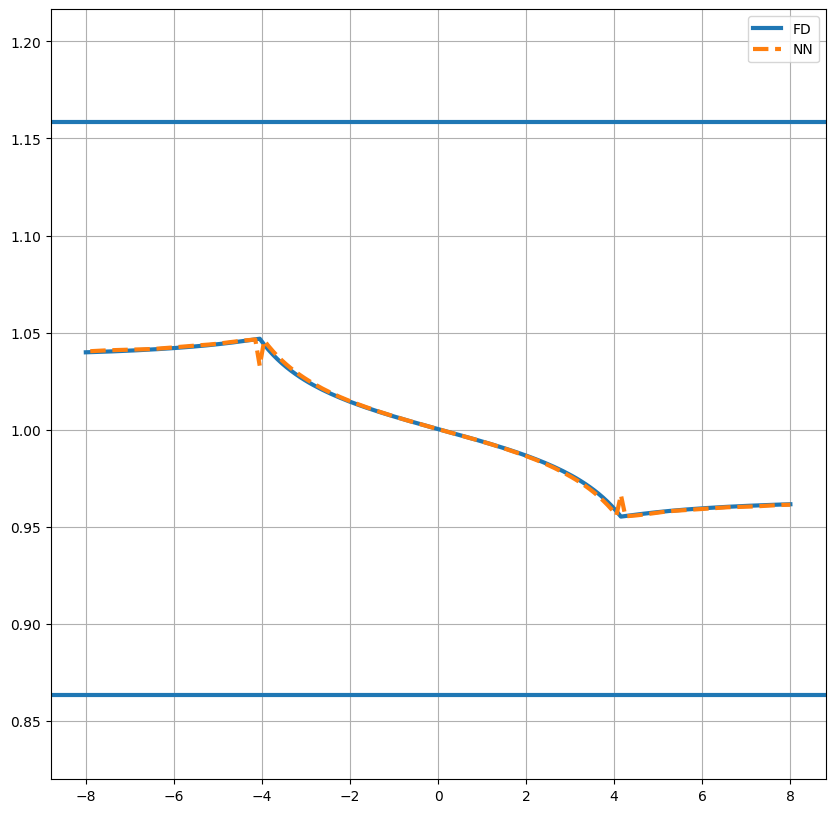

In [35]:
ratio_fd = u_fd[row_length * i:row_length * (i + 1), 0]/u_fd[row_length * i - 1: row_length * (i + 1)-1, 0]
half_index = len(ratio_fd)//2
quarter_index = len(ratio_fd)//4
xy_fd_slice = xy_fd[row_length * i:row_length * (i + 1)][half_index-quarter_index:half_index+quarter_index+1]

u = train_agent.evaluate(xy_fd_slice.cpu())[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()
ratio_nn = u[1:]/u[0:-1]

plt.figure(figsize=(10, 10))
plt.plot(xy_fd_slice[:, 0], ratio_fd[half_index-quarter_index:half_index+quarter_index+1], label='FD', linewidth=3)

# plt.stem(xy[50:65, 0].detach().numpy(), -u[50:65, 0].detach().numpy())
# plt.show()
# plt.stem(xy[75-1:90, 0].detach().numpy(), -u[75-1:90, 0].detach().numpy())
# plt.show()
plt.plot(xy_fd_slice[1:, 0], ratio_nn, linestyle='--', label='NN', linewidth=3)
plt.axhline(y=(n_core**2)/(n_substrate**2), linewidth=3)
plt.axhline(y=(n_substrate**2)/(n_core**2), linewidth=3)
plt.ylim([(n_substrate**2)/(n_core**2)*0.95, (n_core**2)/(n_substrate**2)*1.05])
plt.grid()
plt.legend()

In [36]:
u = base_model(xy.cpu())
u = u/torch.max(torch.abs(u))
u_fd = u_fd/np.max(np.abs(u_fd))

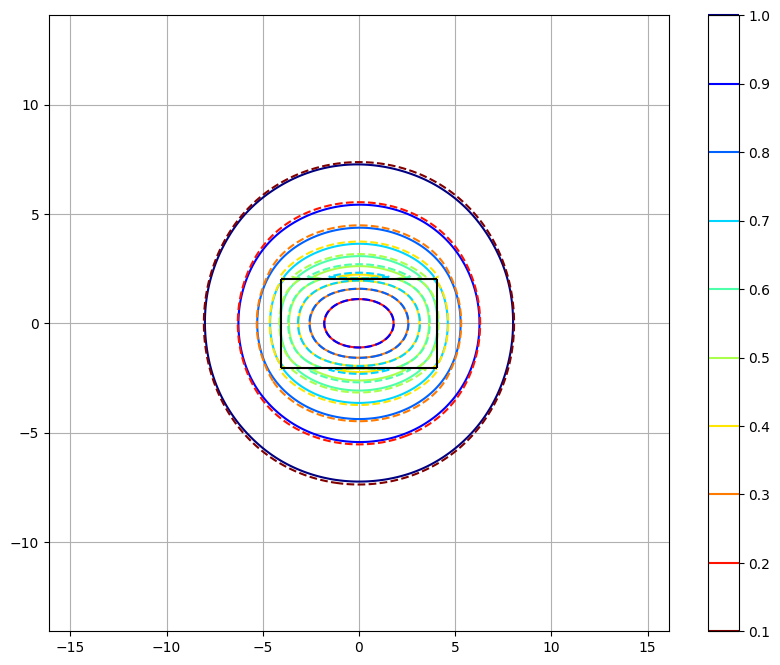

In [37]:
levels = np.linspace(0, np.max(np.abs(u_fd)), 11)[1:]
# levels =  10
plt.figure(figsize=(10, 8))
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), cmap='jet', levels=levels)
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels, cmap='jet_r')
plt.vlines(-core_length_x/2, -core_length_y/2, core_length_y/2, colors='black')
plt.vlines(core_length_x/2, -core_length_y/2, core_length_y/2, colors='black')
plt.hlines(-core_length_y/2, -core_length_x/2, core_length_x/2, colors='black')
plt.hlines(core_length_y/2, -core_length_x/2, core_length_x/2, colors='black')
plt.colorbar()
plt.grid()

In [81]:
print(len(u))

22101


In [82]:
save_folder_path = r"C:\Users\asmaa\Desktop\Amr\2nd Paper\Experiments\TM"

In [86]:
# np.save(save_folder_path + r'\NonPlanar\Single Mode Weakly Guiding\DCNN_field.npy', u.detach().numpy())
# torch.save(base_model.state_dict(), save_folder_path + r'\NonPlanar\Single Mode Weakly Guiding\DCNN.pty')
# np.save(save_folder_path + r'\NonPlanar\Single Mode Weakly Guiding\NN_EI.npy', NN_EI)


# np.save(save_folder_path + r'\NonPlanar\Single Mode Weakly Guiding\FD_field.npy', u_fd)
# np.save(save_folder_path + r'\NonPlanar\sSingle Mode Weakly Guiding\FD_EI.npy', [RI_squared])